# Latent Space Editing Demo

This notebook demonstrates linear editing in the latent space of diffusion models: moving samples along learned attribute directions (e.g., Smiling, Bald, etc.) to modify generated images.

**Prerequisites:**
- Precomputed latent encodings in `data/celeba_validation_noises/noises_<model>.npy`
- Trained classifier weights (W, b) from the classification demo or `train_classifier.py`

In [ ]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
from utils import data_utils
from utils.latent_space_editing_utils import edit_sample, get_orthogonal_direction
from utils.pipeline_wrappers import SDPipelineWrapper

/home/chent/UNETests/.venv-test/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load Pipeline and Data

In [2]:
MODEL_NAME = 'sd15'
NOISES_DIR = '../data/celeba_validation_noises'

print('Loading pipeline...')
pipe = SDPipelineWrapper(model_name=MODEL_NAME)
print('Loading noises...')
noises = data_utils.load_noises(MODEL_NAME)[0]
print('Loading dataset (validation split)...')
ds = data_utils.get_ds('celeba', 'validation')
attr_names = data_utils.get_celeba_attribute_names()

Loading pipeline...


Loading pipeline components...: 100%|██████████| 7/7 [00:01<00:00,  6.53it/s]


Loading noises...
Loading dataset (validation split)...


## 2. Load or Train Classifier Weights

In [3]:
import glob
import pickle

results = {}
results_files = glob.glob(f'../results/results_{MODEL_NAME}_*.pkl')
if results_files:
    # Option A: Load pre-trained results
    with open(sorted(results_files)[-1], 'rb') as f:
        results = pickle.load(f)
    # Prefer W_equiv, b_equiv (in original latent space) from train_classifier
    W_clf = results.get('W_equiv', results['W_clf'])
    b_clf = results.get('b_equiv', results['b_clf'])
    print('Loaded pre-trained classifier')
else:
    # Option B: Train inline (quick LDA)
    print('Training LDA classifier...')
    from sklearn.preprocessing import StandardScaler
    from utils import train_classifier
    
    Y = np.array(ds['attributes'])
    train_idx, test_idx = data_utils.train_test_split(len(noises))
    scaler = StandardScaler().fit(noises[train_idx])
    X_train = scaler.transform(noises[train_idx])
    X_test = scaler.transform(noises[test_idx])
    Y_train, Y_test = Y[train_idx], Y[test_idx]
    
    accs, aucs, Ws, bs = train_classifier.train_all_attr(X_train, Y_train, X_test, Y_test, 'lda')
    W_clf = np.array(Ws)
    b_clf = np.array(bs)
    results = {'pca': None, 'scaler': scaler}
    print('Trained LDA classifier')

Loaded pre-trained classifier


/home/chent/UNETests/.venv-test/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator PCA from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/chent/UNETests/.venv-test/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


## 3. Edit a Sample

Encoding original image to latent space (DDIM inversion)...


150it [01:34,  1.58it/s]                         


Editing attribute: No_Beard
Decoding edited latents back to images...


100%|██████████| 150/150 [00:05<00:00, 27.65it/s]


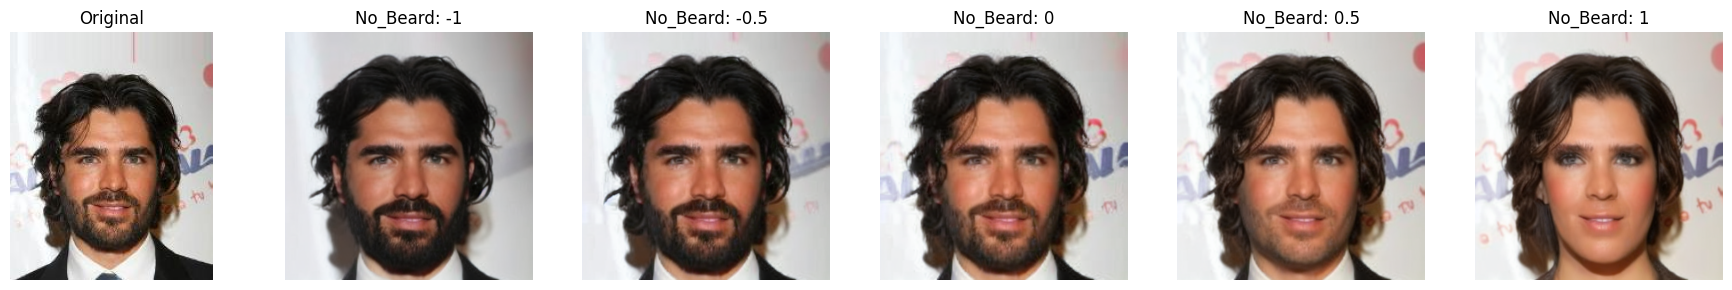

In [4]:
SAMPLE_IDX = 1
ATTR_IDX = 24  # 24 = No_Beard
INTENSITIES = [-1, -0.5, 0, 0.5, 1]  # Negative = less, positive = more; no standard scale since not normalized

orig_img = ds[SAMPLE_IDX]['image']

# Apply DDIM inversion to get latent code for the original image
print('Encoding original image to latent space (DDIM inversion)...')
noise = pipe.encode_images(orig_img).detach().cpu().numpy()

# Allows different forms for results
# W_equiv/b_equiv are already in original latent space; otherwise convert W_clf/b_clf
if 'W_equiv' in results:
    W = results['W_equiv'][ATTR_IDX]
    b = results['b_equiv'][ATTR_IDX]
else:
    W = W_clf[ATTR_IDX]
    b = b_clf[ATTR_IDX]
    if results.get('pca') is not None:
        pca, scaler = results['pca'], results['scaler']
        W = (W * scaler.scale_) @ pca.components_
    elif results.get('scaler') is not None:
        W = W * results['scaler'].scale_

attr_name = attr_names.get(ATTR_IDX, f'attr_{ATTR_IDX}')
print(f'Editing attribute: {attr_name}')

# Edit the sample in latent space
edited_latents = []
for intensity in INTENSITIES:
    edited = edit_sample(noise, W, intensity)
    edited_latents.append(edited)

# Decode the edited latents back to images
print('Decoding edited latents back to images...')
images = []
for latent in edited_latents:
    img = pipe.decode_latent(latent.reshape(1, -1))
    images.append(np.array(img))

# Also include original from dataset
images = [np.array(orig_img)] + images

# Show edited images
fig, axes = plt.subplots(1, len(images), figsize=(3*len(images), 3))
labels = ['Original'] + [f'{attr_name}: {i}' for i in INTENSITIES]
for ax, img, label in zip(axes, images, labels):
    ax.imshow(img)
    ax.set_title(label)
    ax.axis('off')
plt.tight_layout()
plt.show()

# 4. Edit a Sample Without Affecting an Attribute

Encoding original image to latent space (DDIM inversion)...


150it [00:05, 27.82it/s]                         


Editing attribute: No_Beard, orthogonal to: Male
Decoding edited latents back to images...


100%|██████████| 150/150 [00:05<00:00, 27.06it/s]


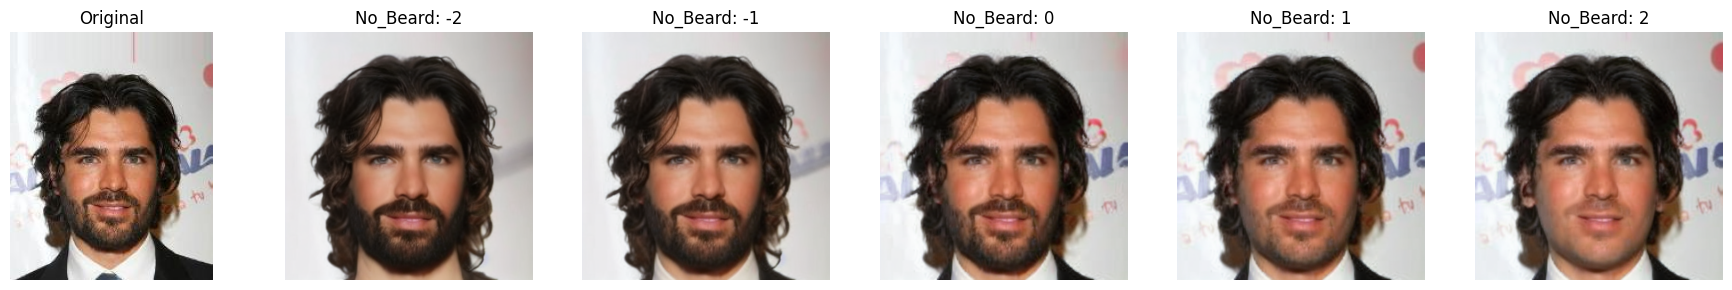

In [5]:
SAMPLE_IDX = 1
ATTR_IDX = 24  # 24 = No_Beard
ORTHOGONAL_ATT_IDX = 20 # 20 = Male
INTENSITIES = [-2, -1, 0, 1, 2]  # Negative = less, positive = more; no standard scale since not normalized

orig_img = ds[SAMPLE_IDX]['image']

# Apply DDIM inversion to get latent code for the original image
print('Encoding original image to latent space (DDIM inversion)...')
noise = pipe.encode_images(orig_img).detach().cpu().numpy()

# Allows different forms for results
# W_equiv/b_equiv are already in original latent space; otherwise convert W_clf/b_clf
if 'W_equiv' in results:
    W = results['W_equiv'][ATTR_IDX]
    b = results['b_equiv'][ATTR_IDX]
    W_orth = results['W_equiv'][ORTHOGONAL_ATT_IDX]
else:
    W = W_clf[ATTR_IDX]
    b = b_clf[ATTR_IDX]
    W_orth = W_clf[ORTHOGONAL_ATT_IDX]
    if results.get('pca') is not None:
        pca, scaler = results['pca'], results['scaler']
        W = (W * scaler.scale_) @ pca.components_
        W_orth = (W_orth * scaler.scale_) @ pca.components_
    elif results.get('scaler') is not None:
        W = W * results['scaler'].scale_
        W_orth = W_orth * results['scaler'].scale_

W = get_orthogonal_direction(W, W_orth)

attr_name = attr_names.get(ATTR_IDX, f'attr_{ATTR_IDX}')
orthogonal_attr_name = attr_names.get(ORTHOGONAL_ATT_IDX, f'attr_{ORTHOGONAL_ATT_IDX}')
print(f'Editing attribute: {attr_name}, orthogonal to: {orthogonal_attr_name}')

# Edit the sample in latent space
edited_latents = []
for intensity in INTENSITIES:
    edited = edit_sample(noise, W, intensity, )
    edited_latents.append(edited)

# Decode the edited latents back to images
print('Decoding edited latents back to images...')
images = []
for latent in edited_latents:
    img = pipe.decode_latent(latent.reshape(1, -1))
    images.append(np.array(img))

# Also include original from dataset
images = [np.array(orig_img)] + images

# Show edited images
fig, axes = plt.subplots(1, len(images), figsize=(3*len(images), 3))
labels = ['Original'] + [f'{attr_name}: {i}' for i in INTENSITIES]
for ax, img, label in zip(axes, images, labels):
    ax.imshow(img)
    ax.set_title(label)
    ax.axis('off')
plt.tight_layout()
plt.show()